1000枚の学習用画像を生成中...

AIの学習を開始します(10エポック)...
Epoch 1/10, Loss: 0.0261
Epoch 2/10, Loss: 0.0026
Epoch 3/10, Loss: 0.0009
Epoch 4/10, Loss: 0.0006
Epoch 5/10, Loss: 0.0004
Epoch 6/10, Loss: 0.0003
Epoch 7/10, Loss: 0.0005
Epoch 8/10, Loss: 0.0002
Epoch 9/10, Loss: 0.0002
Epoch 10/10, Loss: 0.0003

学習完了。未知の画像でテストします。


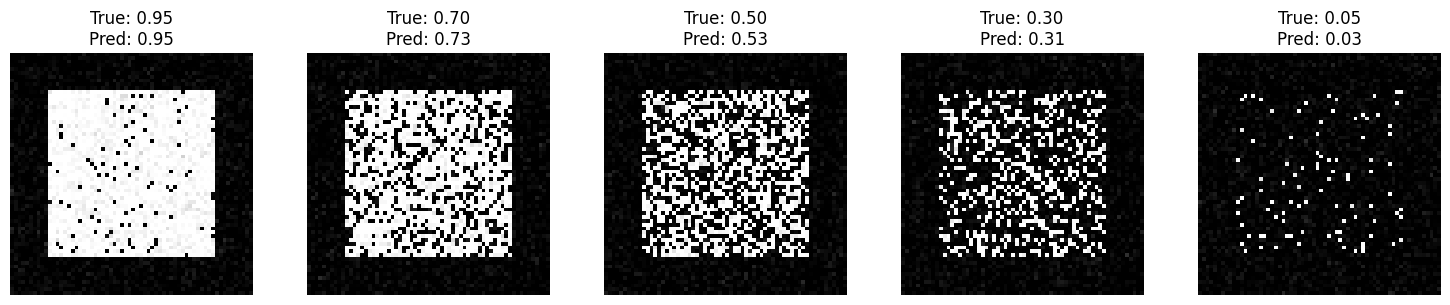

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. 疑似データセットの作成クラス
# ---------------------------------------------------------
class MarkerDataset(torch.utils.data.Dataset):
    def __init__(self, num_samples=1000, img_size=64):
        self.num_samples = num_samples
        self.img_size = img_size
        self.data = []
        self.labels = []

        print(f"{num_samples}枚の学習用画像を生成中...")
        for _ in range(num_samples):
            # 0%〜100%のランダムな残存率(正解ラベル)を決める
            rate = np.random.rand()

            # 画像生成: ベースは真っ黒(0)
            img = np.zeros((img_size, img_size), dtype=np.float32)

            # 中央にマーカー領域(正方形)を定義
            margin = 10
            # マーカーの元の形（ここでは正方形と仮定）
            # rateの確率でピクセルを残す（拭き残しをシミュレート）
            mask = np.random.choice([0.0, 1.0],
                                    size=(img_size-2*margin, img_size-2*margin),
                                    p=[1-rate, rate])

            img[margin:-margin, margin:-margin] = mask

            # 少しノイズを加える（現実のカメラ画像に近づける）
            noise = np.random.normal(0, 0.05, img.shape)
            img = img + noise
            img = np.clip(img, 0, 1) # 0-1の範囲に収める

            self.data.append(img)
            self.labels.append(rate)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        # PyTorchが扱える形式(Channel, Height, Width)に変換
        img = torch.tensor(self.data[idx], dtype=torch.float32).unsqueeze(0)
        label = torch.tensor(self.labels[idx], dtype=torch.float32).unsqueeze(0)
        return img, label

# ---------------------------------------------------------
# 2. 回帰分析用 AIモデルの定義 (CNN)
# ---------------------------------------------------------
class CleaningRatePredictor(nn.Module):
    def __init__(self):
        super(CleaningRatePredictor, self).__init__()
        # 画像の特徴を抽出する部分
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), # 1ch -> 16ch
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # サイズを半分に圧縮

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # さらに半分に

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2) # さらに半分に (64x64 -> 8x8になる)
        )

        # 特徴から数値(0.0-1.0)を算出する部分
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid() # 出力を必ず0〜1の範囲にする関数
        )

    def forward(self, x):
        x = self.features(x)
        x = self.regressor(x)
        return x

# ---------------------------------------------------------
# 3. 学習と評価の実行
# ---------------------------------------------------------
def run_demo():
    # データセットの準備
    dataset = MarkerDataset(num_samples=1000, img_size=64)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)

    # モデルと最適化手法の準備
    model = CleaningRatePredictor()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss() # 平均二乗誤差（正解と予測のズレを最小化する）

    # --- 学習ループ ---
    print("\nAIの学習を開始します(10エポック)...")
    model.train()
    for epoch in range(10):
        total_loss = 0
        for imgs, labels in dataloader:
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1}/10, Loss: {total_loss/len(dataloader):.4f}")

    # --- テスト(推論) ---
    print("\n学習完了。未知の画像でテストします。")
    model.eval()

    # テスト用に5枚生成
    test_rates = [0.95, 0.70, 0.50, 0.30, 0.05] # 意図的に作る正解値

    plt.figure(figsize=(15, 3))

    for i, true_rate in enumerate(test_rates):
        # テスト画像作成(データセットと同じロジック)
        img_np = np.zeros((64, 64), dtype=np.float32)
        margin = 10
        mask = np.random.choice([0.0, 1.0], size=(44, 44), p=[1-true_rate, true_rate])
        img_np[margin:-margin, margin:-margin] = mask
        img_np = img_np + np.random.normal(0, 0.05, img_np.shape)
        img_tensor = torch.tensor(img_np, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

        # AIによる予測実行
        with torch.no_grad():
            prediction = model(img_tensor).item()

        # 結果表示
        ax = plt.subplot(1, 5, i+1)
        ax.imshow(img_np, cmap='gray', vmin=0, vmax=1)
        ax.set_title(f"True: {true_rate:.2f}\nPred: {prediction:.2f}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_demo()
